In [1]:
#Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.core.display import display, HTML

#Adjusting the size of the output windows
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))


#Importing and viewing the data
ppg = pd.read_csv('ppg2008.csv')
costcos = pd.read_csv('costcos-geocoded.csv')

print(ppg.head())
print(costcos.head())

           Name     G   MIN   PTS   FGM   FGA    FGP  FTM  FTA    FTP  ...  \
0    Dwyane Wade   79  38.6  30.2  10.8  22.0  0.491  7.5  9.8  0.765  ...   
1   LeBron James   81  37.7  28.4   9.7  19.9  0.489  7.3  9.4  0.780  ...   
2    Kobe Bryant   82  36.2  26.8   9.8  20.9  0.467  5.9  6.9  0.856  ...   
3  Dirk Nowitzki   81  37.7  25.9   9.6  20.0  0.479  6.0  6.7  0.890  ...   
4  Danny Granger   67  36.2  25.8   8.5  19.1  0.447  6.0  6.9  0.878  ...   

   3PA    3PP  ORB  DRB  TRB  AST  STL  BLK   TO   PF  
0  3.5  0.317  1.1  3.9  5.0  7.5  2.2  1.3  3.4  2.3  
1  4.7  0.344  1.3  6.3  7.6  7.2  1.7  1.1  3.0  1.7  
2  4.1  0.351  1.1  4.1  5.2  4.9  1.5  0.5  2.6  2.3  
3  2.1  0.359  1.1  7.3  8.4  2.4  0.8  0.8  1.9  2.2  
4  6.7  0.404  0.7  4.4  5.1  2.7  1.0  1.4  2.5  3.1  

[5 rows x 21 columns]
                     Address        City    State    Zip Code   Latitude  \
0   1205 N. Memorial Parkway  Huntsville  Alabama  35801-5930  34.743095   
1       3650 Galleri

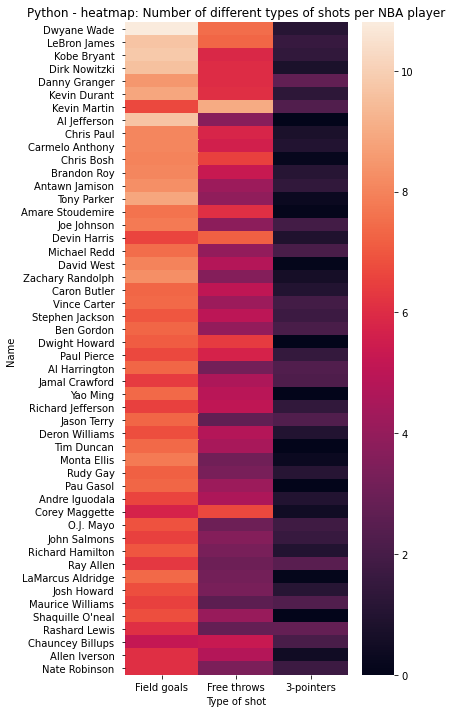

In [2]:
#Building the heatmap
#I will visualize the number of different types of special shots 
#(field goals, free throws, and 3-pointers) made by each player

#The dataset contains many numbers, so only the columns of special shots will be subset
newdf = ppg.set_index(ppg.columns[0])[['FGM', 'FTM', '3PM']]

#Renaming the columns to make them easier to understand
newdf.columns = ['Field goals', 'Free throws', '3-pointers']

#Generating the heatmap
plt.figure(figsize=(5, 12))
sns.heatmap(newdf)
plt.xlabel('Type of shot')
plt.title('Python - heatmap: Number of different types of shots per NBA player')
plt.show()

In [3]:
#Building the spatial chart 
#I will view the spatial locations of each US Costco

lat = costcos['Latitude']
lon = costcos['Longitude']

In [4]:
#Generating the spatial chart
import folium as f
from branca.element import Figure

fig5 = Figure(height=550,width=750)
m = f.Map(location = [lat[0], lon[0]], tiles = 'cartodbpositron', zoom_start = 2.5)
fig5.add_child(m)

for a, b in zip(lat, lon):
    f.Marker(location=[a, b]).add_to(m)

    
#Adding the title
title_html = '''
             <h3 align="center" style="font-size:16px"><b>{}</b></h3>
             '''.format('Python - spatial chart: US Costco locations')   

m.get_root().html.add_child(f.Element(title_html))
m

In [5]:
#Building the contour chart
#I will generate artificial elevations to plot along the latitudes and longitudes of the Costco dataset

#Setting the x and y values and making the contour grid
lati = costcos['Latitude']
long = costcos['Longitude']
X, Y = np.meshgrid(long, lati)

#Generating the artificial elevations using the following equation
Z = X**2 + Y**2

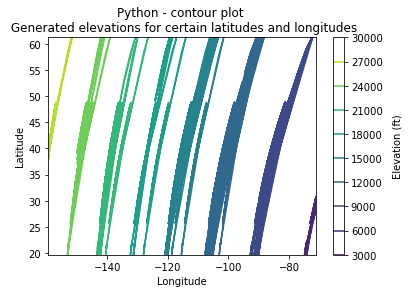

In [6]:
#Generating the contour chart
fig,ax=plt.subplots(1, 1)
f = ax.contour(X, Y, Z)
clb = fig.colorbar(f, ax = [ax], location = 'right')
clb.set_label('Elevation (ft)', labelpad = 10, y = 0.5, rotation = 90)
ax.set_title('Python - contour plot \n Generated elevations for certain latitudes and longitudes')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()